In [1]:
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys
from pathlib import Path
import joblib
import time

from gplearn.genetic import SymbolicClassifier

import torch
import torch.nn as nn
from scipy.special import label

sns.set_style("ticks")

In [2]:
# Data
from src.debbirth.data.schema import DatasetSpec
from src.debbirth.data.load import load_data_gp, load_data_pytorch
# GP
from src.debbirth.models.gp.train import load_gp_run
# NN
from src.debbirth.models.nn.train import load_trained_nn
# Evaluate
from src.debbirth.evaluate.metrics import *
from src.debbirth.evaluate.compare import *
# Utils
from src.debbirth.utils.results import *

# Setup

In [3]:
save_figure_dir = Path(
    r"C:\Users\diogo\OneDrive - Universidade de Lisboa\Conferences\2026\World Conference on Computational Intelligence\figures")

best_models_path = Path().cwd().parent / "results" / "models"


# Load models

## Load Genetic Programming model

In [4]:
gp_model_path = best_models_path / "DEBBirthGP"
loaded_gp = load_gp_run(gp_model_path)

In [5]:
gp = loaded_gp["model"]
gp_train_cfg = loaded_gp["train_cfg"]

In [6]:
print(f"Depth of GP model: {gp._program.depth_}")
print(f"Length of GP model: {gp._program.length_}")

Depth of GP model: 22
Length of GP model: 141


## Load Neural Network model

In [7]:
nn_model_path = best_models_path / "DEBBirthNet"
loaded_nn = load_trained_nn(nn_model_path)

In [8]:
nn = loaded_nn["model"]
scaler = loaded_nn["scaler"]
nn_train_cfg = loaded_nn["train_cfg"]

# Load data


In [9]:
data_spec = DatasetSpec(feature_set="dimensionless")

## Genetic Programing

In [10]:
features, targets = load_data_gp(gp_train_cfg)

## Neural Network

In [11]:
scaled_input_data, targets_nn, dataloaders, datasets, scaler = load_data_pytorch(config=nn_train_cfg, scaler=scaler)


# Get test set predictions

## Genetic Programing

In [12]:
gp_test_metrics = BinaryMetrics.load_json(gp_model_path / "metrics" / "test_metrics.json")
gp_test_metrics

BinaryMetrics(accuracy=0.9602480124006201, precision_pos=0.931007315700619, recall_pos=0.9784717293588834, f1_pos=0.9541496049368475, precision_neg=0.9836242576929998, recall_neg=0.9469034213945431, f1_neg=0.9649146034688203, precision_macro=0.9573157866968094, recall_macro=0.9626875753767132, f1_macro=0.959532104202834, auroc=0.9948095739990696, avg_precision=0.9925519164765606, auroc_macro=0.9948095739990694, avg_precision_macro=0.9945286556299227, tp=8272, fp=613, tn=10932, fn=182)

In [37]:
# Time to predict on test set (vectorized prediction kept for metrics; measure per-sample times separately)
start_time = time.time()
gp_test_set_probs = gp.predict_proba(features["test"])
gp_test_set_preds = np.argmax(gp_test_set_probs, axis=1)
end_time = time.time()
gp_inference_time_total = end_time - start_time
print(f"GP inference time on test set (vectorized): {gp_inference_time_total * 1000:.3f} ms")

# Per-sample timing (high-resolution)
gp_times = []
X_gp_test = features["test"]
n_gp = len(targets["test"])
for i in range(n_gp):
    x = X_gp_test[i:i+1]  # keep 2D shape
    t0 = time.perf_counter()
    _ = gp.predict_proba(x)
    t1 = time.perf_counter()
    gp_times.append(t1 - t0)

gp_times = np.asarray(gp_times)  # seconds per sample
gp_mean = gp_times.mean()
gp_std = gp_times.std()
print(f"GP per-sample inference: mean {gp_mean*1e6:.3f} μs, std {gp_std*1e6:.3f} μs, total {gp_times.sum()*1000:.3f} ms")

# Save per-sample times to metrics folder
# np.save(gp_model_path / "metrics" / "gp_inference_times.npy", gp_times)


GP inference time on test set (vectorized): 0.000 ms
GP per-sample inference: mean 337.449 μs, std 34.910 μs, total 6748.649 ms


## Neural Network

In [32]:
nn_test_metrics = BinaryMetrics.load_json(nn_model_path / "metrics" / "test_metrics.json")
nn_test_metrics

BinaryMetrics(accuracy=0.9783989199459973, precision_pos=0.955071477195371, recall_pos=0.9957416607523066, f1_pos=0.9749826268241835, precision_neg=0.9967814036656236, recall_neg=0.9656994369857081, f1_neg=0.9809942806863177, precision_macro=0.9759264404304973, recall_macro=0.9807205488690074, f1_macro=0.9779884537552506, auroc=0.9993598710592662, avg_precision=0.9991427013305515, auroc_macro=0.9993598710592662, avg_precision_macro=0.9993386094530703, tp=8418, fp=396, tn=11149, fn=36)

In [38]:
# Time to predict on test set (vectorized prediction kept for metrics; measure per-sample times separately)
start_time = time.time()
nn_test_set_probs = nn.predict_proba(scaled_input_data["test"])
# keep same post-processing as before
if isinstance(nn_test_set_probs, torch.Tensor):
    nn_test_set_preds = torch.round(nn_test_set_probs)
else:
    nn_test_set_preds = np.round(nn_test_set_probs)
end_time = time.time()
nn_inference_time_total = end_time - start_time
print(f"NN inference time on test set (vectorized): {nn_inference_time_total * 1000:.3f} ms")

# Per-sample timing (high-resolution)
nn_times = []
X_nn_test = scaled_input_data["test"]
n_nn = len(targets_nn["test"])
for i in range(n_nn):
    x = X_nn_test[i:i+1]
    t0 = time.perf_counter()
    _ = nn.predict_proba(x)
    t1 = time.perf_counter()
    nn_times.append(t1 - t0)

nn_times = np.asarray(nn_times)  # seconds per sample
nn_mean = nn_times.mean()
nn_std = nn_times.std()
print(f"NN per-sample inference: mean {nn_mean*1e6:.3f} μs, std {nn_std*1e6:.3f} μs, total {nn_times.sum()*1000:.3f} ms")

# Save per-sample times to metrics folder
# np.save(nn_model_path / "metrics" / "nn_inference_times.npy", nn_times)


NN inference time on test set (vectorized): 0.000 ms
NN per-sample inference: mean 191.247 μs, std 24.638 μs, total 3824.753 ms


# Test set comparison

In [63]:
# Load test set
data_dir = gp_train_cfg.data_dir
test_df = pd.read_csv(data_dir / "test.csv")
test_df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message
0,1.144681,8.032760,0.211143,0.757319,5.107204e-16,6.717920e-08,True,False,False,True,0.180274,none,NaN
1,52.261747,0.000106,1.213111,0.737426,NaN,NaN,False,False,False,False,0.061433,none,NaN
2,5.750439,0.135090,0.237359,0.153462,5.616690e-01,6.590347e-01,False,True,False,True,0.081755,none,NaN
3,56.242412,0.000228,0.435221,0.921968,7.456144e-01,8.997763e-02,True,True,True,True,0.058544,none,NaN
4,0.729798,0.016903,8.978091,0.639879,NaN,NaN,False,False,False,False,0.156527,none,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19994,0.009808,0.089822,25.134367,0.791762,NaN,NaN,False,False,False,False,0.104861,none,NaN
19995,0.041028,0.267050,6.331615,0.999150,NaN,NaN,False,False,False,False,0.098295,none,NaN
19996,10.752230,0.724151,1.641248,0.693342,NaN,NaN,False,False,False,False,0.105468,none,NaN
19997,0.041395,0.000233,0.020778,0.379692,1.621203e-01,1.313352e+01,True,True,True,True,0.036222,none,NaN


## Metrics table

In [16]:
results_df = compile_metrics(metrics_dict={
    "GP": gp_test_metrics,
    "NN": nn_test_metrics,
})

In [73]:
# Compute MCC separately for both models (not included in saved metrics)
from sklearn.metrics import matthews_corrcoef
gp_mcc = matthews_corrcoef(targets["test"], gp_test_set_preds)
nn_mcc = matthews_corrcoef(targets_nn["test"], nn_test_set_preds.cpu().detach().numpy() if isinstance(nn_test_set_preds, torch.Tensor) else nn_test_set_preds)
results_df["MCC"] = [gp_mcc, nn_mcc]

In [74]:
results_df

,accuracy,precision_pos,recall_pos,f1_pos,precision_neg,recall_neg,f1_neg,precision_macro,recall_macro,f1_macro,auroc,avg_precision,auroc_macro,avg_precision_macro,tp,fp,tn,fn,MCC
GP,0.960248,0.931007,0.978472,0.95415,0.983624,0.946903,0.964915,0.957316,0.962688,0.959532,0.99481,0.992552,0.99481,0.994529,8272.0,613.0,10932.0,182.0,0.919988
NN,0.978399,0.955071,0.995742,0.974983,0.996781,0.965699,0.980994,0.975926,0.980721,0.977988,0.99936,0.999143,0.99936,0.999339,8418.0,396.0,11149.0,36.0,0.957668


In [17]:
latex_table_str = format_metrics_latex_table(results_df,
                                             columns=['accuracy', 'precision_macro', 'recall_macro', 'f1_macro', ],
                                             )
print(latex_table_str)

\begin{tabular}{lrrrr}
\toprule
Model & Accuracy & Precision & Recall & F1 \\
\midrule
GP & 0.9602 & 0.9573 & 0.9627 & 0.9595 \\
NN & 0.9784 & 0.9759 & 0.9807 & 0.9780 \\
\bottomrule
\end{tabular}


In [18]:
# Save results table
results_path = Path().cwd().parent / "results" / "tables"

## Per-class metrics table

In [76]:
per_class_latex_table_str = format_per_class_metrics_latex_table(results_df, extra_metrics=['accuracy', 'auroc', 'MCC'],)
print(per_class_latex_table_str)

\begin{tabular}{lrrrrrrrrr}
\toprule
\multirow{2}{*}{Model} & \multicolumn{3}{c}{Birth is reached} & \multicolumn{3}{c}{Birth is not reached} & \multirow{2}{*}{Accuracy} & \multirow{2}{*}{AUROC} & \multirow{2}{*}{MCC} \\
 & Precision & Recall & F1-score & Precision & Recall & F1-score &  &  &  \\
\midrule
GP & 0.9310 & 0.9785 & 0.9541 & 0.9836 & 0.9469 & 0.9649 & 0.9602 & 0.9948 & 0.9200 \\
NN & 0.9551 & 0.9957 & 0.9750 & 0.9968 & 0.9657 & 0.9810 & 0.9784 & 0.9994 & 0.9577 \\
\bottomrule
\end{tabular}


## Curve plots

In [20]:
from sklearn.metrics import precision_recall_curve, average_precision_score, roc_curve, auc


In [21]:
# True labels (ensure numpy array)
y_test = targets["test"]
if isinstance(y_test, torch.Tensor):
    y_test = y_test.cpu().numpy()
y_test = np.asarray(y_test)

# GP: ensure we have probability for class 0
gp_probs = np.asarray(gp_test_set_probs)
if gp_probs.ndim == 2 and gp_probs.shape[1] >= 1:
    gp_prob0 = gp_probs[:, 0]
    gp_prob1 = gp_probs[:, 1]
else:
    # if single-column probs assume they represent class 1, so invert
    gp_prob0 = 1.0 - gp_probs.squeeze()
    gp_prob1 = gp_probs.squeeze()

# NN: convert to numpy and obtain prob for class 0
if isinstance(nn_test_set_probs, torch.Tensor):
    nn_p = nn_test_set_probs.detach().cpu().numpy()
else:
    nn_p = np.asarray(nn_test_set_probs)

# nn_p may be shape (n,1) or (n,) or (n,2)
if nn_p.ndim == 2:
    if nn_p.shape[1] == 1:
        nn_prob1 = nn_p.squeeze()
    else:
        # assume column 1 is prob of class 1
        nn_prob1 = nn_p[:, 1]
else:
    nn_prob1 = nn_p.squeeze()

nn_prob0 = 1.0 - nn_prob1

# Construct binary labels where positive = class 0
y_pos0 = (y_test == 0).astype(int)

### Precision recall curve for birth is reached

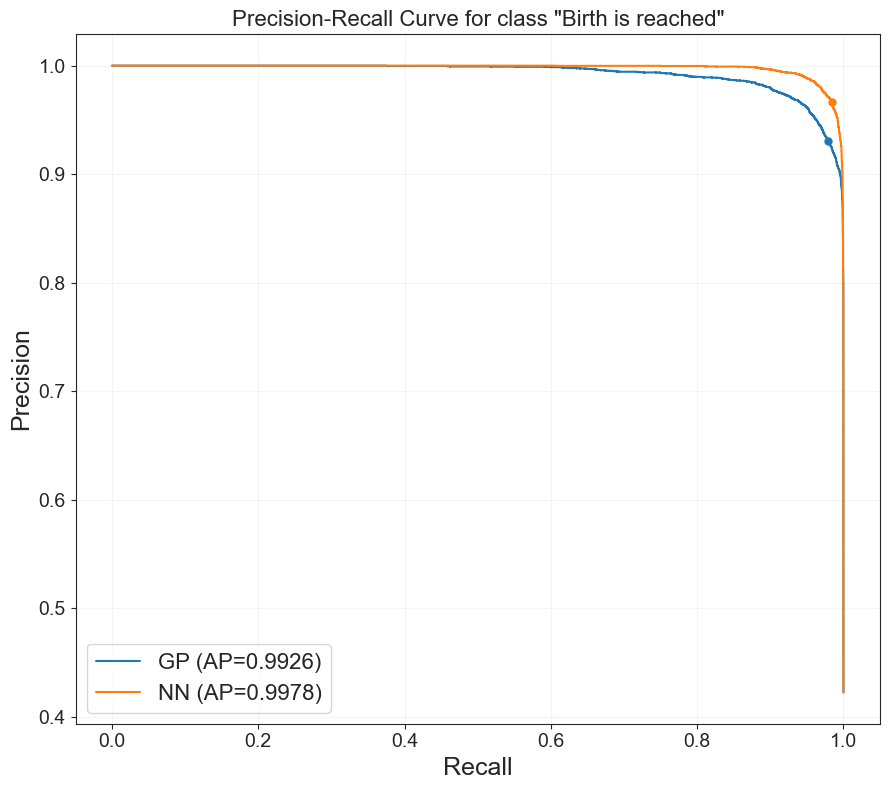

In [22]:

# Precision-Recall curve (positive class = y == 1), compare GP vs NN
# Compute precision-recall curves and average precision
gp_prec, gp_rec, gp_thresh = precision_recall_curve(y_test, gp_prob1)
nn_prec, nn_rec, nn_thresh = precision_recall_curve(y_test, nn_prob1)
gp_ap = average_precision_score(y_test, gp_prob1)
nn_ap = average_precision_score(y_test, nn_prob1)
# Plot using explicit Figure and Axes (use ax only, avoid plt.* plotting calls)
fig, ax = plt.subplots(figsize=(9, 8))
ax.step(gp_rec, gp_prec, where="post", label=f"GP (AP={gp_ap:.4f})")
ax.step(nn_rec, nn_prec, where="post", label=f"NN (AP={nn_ap:.4f})")
# Add dot at threshold=0.5
gp_op_idx = np.argmin(np.abs(gp_thresh - 0.5))
nn_op_idx = np.argmin(np.abs(nn_thresh - 0.5))
ax.plot(gp_rec[gp_op_idx], gp_prec[gp_op_idx], 'o', markersize=5, color='tab:blue')
ax.plot(nn_rec[nn_op_idx], nn_prec[nn_op_idx], 'o', markersize=5, color='tab:orange')


ax.set_xlabel("Recall", fontsize=18)
ax.set_ylabel("Precision", fontsize=18)
ax.set_title('Precision-Recall Curve for class "Birth is reached"', fontsize=16)
ax.legend(loc="best", fontsize=16)
ax.tick_params(axis='both', which='major', labelsize=14)

ax.grid(alpha=0.2)
fig.tight_layout()


In [23]:
# Save precision recall curve in .png, .pdf, .svg formats
save_figure_in_formats(fig, outdir=save_figure_dir, filename="precision_recall_curve_birth", dpi=300)

### Precision recall curve for birth is not reached

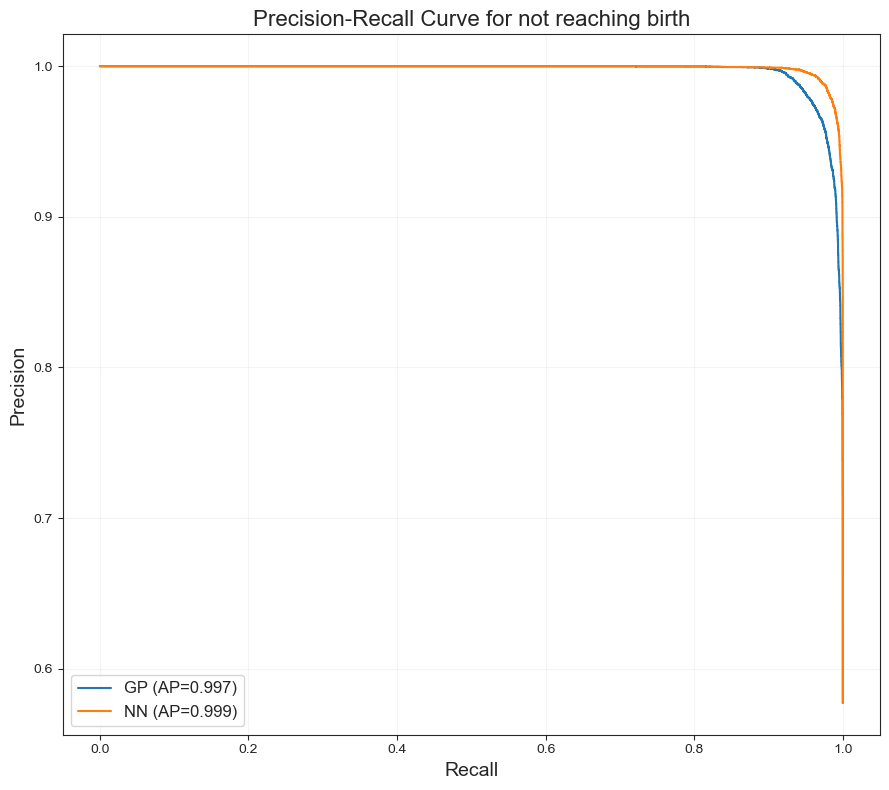

In [24]:
# Precision-Recall curve (positive class = y == 0), compare GP vs NN

# Compute precision-recall curves and average precision
gp_prec, gp_rec, _ = precision_recall_curve(y_pos0, gp_prob0)
nn_prec, nn_rec, _ = precision_recall_curve(y_pos0, nn_prob0)

gp_ap = average_precision_score(y_pos0, gp_prob0)
nn_ap = average_precision_score(y_pos0, nn_prob0)

# Plot using explicit Figure and Axes (use ax only, avoid plt.* plotting calls)
fig, ax = plt.subplots(figsize=(9, 8))
ax.step(gp_rec, gp_prec, where="post", label=f"GP (AP={gp_ap:.3f})")
ax.step(nn_rec, nn_prec, where="post", label=f"NN (AP={nn_ap:.3f})")
ax.set_xlabel("Recall", fontsize=14)
ax.set_ylabel("Precision", fontsize=14)
ax.set_title("Precision-Recall Curve for not reaching birth", fontsize=16)
ax.legend(loc="best", fontsize=12)
ax.grid(alpha=0.2)
fig.tight_layout()


In [25]:
# Save precision recall curve in .png, .pdf, .svg formats
save_figure_in_formats(fig, outdir=save_figure_dir, filename="precision_recall_curve_no_birth", dpi=300)

### AUC-ROC curve

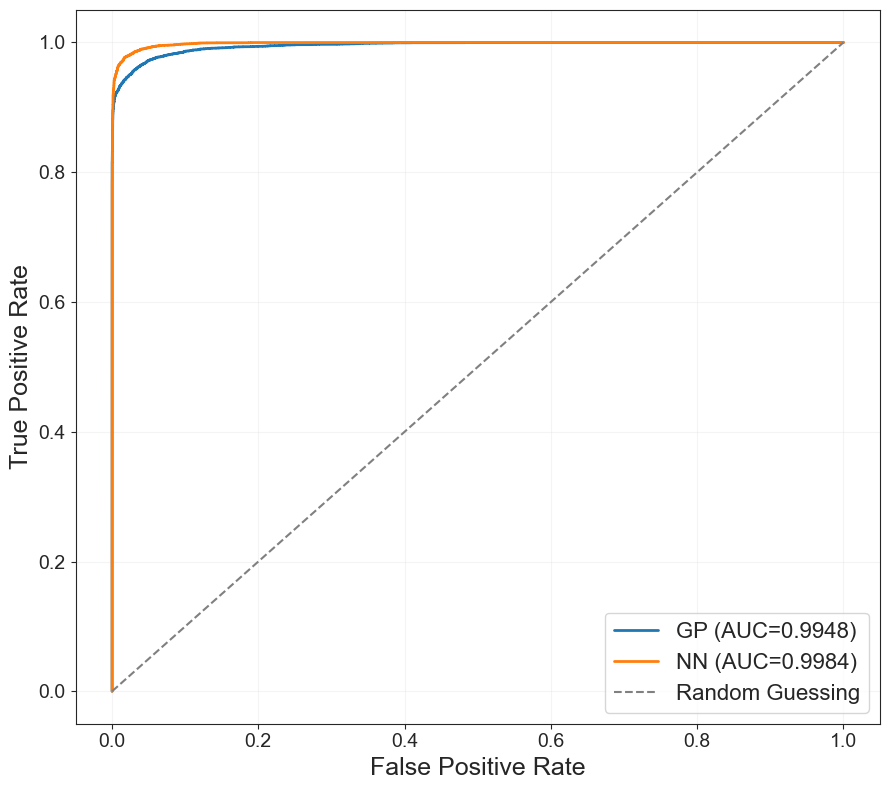

In [26]:
# AUC-ROC curve (positive class = y == 0), compare GP vs NN
# Compute ROC curves and AUC
gp_fpr, gp_tpr, _ = roc_curve(y_pos0, gp_prob0)
nn_fpr, nn_tpr, _ = roc_curve(y_pos0, nn_prob0)
gp_auc = auc(gp_fpr, gp_tpr)
nn_auc = auc(nn_fpr, nn_tpr)
# Plot using explicit Figure and Axes (use ax only, avoid plt.* plotting calls)
fig, ax = plt.subplots(figsize=(9, 8))
ax.plot(gp_fpr, gp_tpr, label=f"GP (AUC={gp_auc:.4f})", linewidth=2)
ax.plot(nn_fpr, nn_tpr, label=f"NN (AUC={nn_auc:.4f})", linewidth=2)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guessing")
ax.set_xlabel("False Positive Rate", fontsize=18)
ax.set_ylabel("True Positive Rate", fontsize=18)
# ax.set_title("AUC", fontsize=16)
ax.legend(loc="best", fontsize=16)
# Set ticks font size
ax.tick_params(axis='both', which='major', labelsize=14)
ax.grid(alpha=0.2)
fig.tight_layout()

In [27]:
save_figure_in_formats(fig, outdir=save_figure_dir, filename="auc_roc_curve", dpi=300)

## Performance on estimation halting condition

In [64]:
# Get indices of samples that halted due to time limit
time_limit_indices = np.where(test_df['error_type'] == 'time_limit_reached')
time_limit_indices

(array([   39,    66,   126,   436,   684,   942,   968,  1439,  1850,
         1971,  2007,  2762,  3220,  3388,  3460,  3480,  3972,  4320,
         4506,  4587,  4990,  5494,  5889,  6088,  6242,  7113,  7114,
         7612,  8097,  9479,  9923, 10063, 10987, 11012, 11388, 11845,
        12469, 12483, 12507, 12637, 13755, 13793, 13998, 14306, 14332,
        14384, 14947, 15333, 15659, 15664, 15861, 16232, 16554, 17725,
        17862, 17905, 17959, 18284, 18757, 18804, 18876, 18983, 19531,
        19717, 19800]),)

In [68]:
limit_df = test_df.iloc[time_limit_indices].copy()
limit_df['k*v_Hb'] = limit_df['k'] * limit_df['v_Hb']
limit_df

,g,k,v_Hb,f,lb,tb,lb<f,k*vHb<c,reached_birth,success,execution_time,error_type,error_message,k*v_Hb
39,0.007028,0.000408,2022.657316,0.649537,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,0.825292
66,0.008878,0.000401,5696.295561,0.892507,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,2.286803
126,0.001684,0.002301,17.374841,0.563514,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,0.039983
436,0.002328,0.002344,20.264887,0.614148,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,0.047500
684,0.001393,0.003674,745.595424,0.829335,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,2.739198
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18876,0.005502,0.000303,408.773634,0.358149,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,0.123943
18983,0.004504,0.000321,1.564748,0.416077,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,0.000502
19531,0.001054,0.001385,1691.393265,0.826494,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,2.342970
19717,0.003717,0.004138,2.879530,0.326605,0.0,0.0,False,False,False,False,6.0,time_limit_reached,Maximum execution time exceeded,0.011916


In [50]:
# Check if models predicted infeasible for time limit samples
gp_time_limit_preds = gp_test_set_preds[time_limit_indices]
nn_time_limit_preds = nn_test_set_preds[time_limit_indices]

gp_infeasible_count = np.sum(gp_time_limit_preds == 0)
nn_infeasible_count = torch.sum(nn_time_limit_preds == 0)

print(f"GP predicted infeasible for {gp_infeasible_count} out of {len(time_limit_indices[0])} time limit samples.")
print(f"NN predicted infeasible for {nn_infeasible_count} out of {len(time_limit_indices[0])} time limit samples.")

GP predicted infeasible for 51 out of 65 time limit samples.
NN predicted infeasible for 61 out of 65 time limit samples.


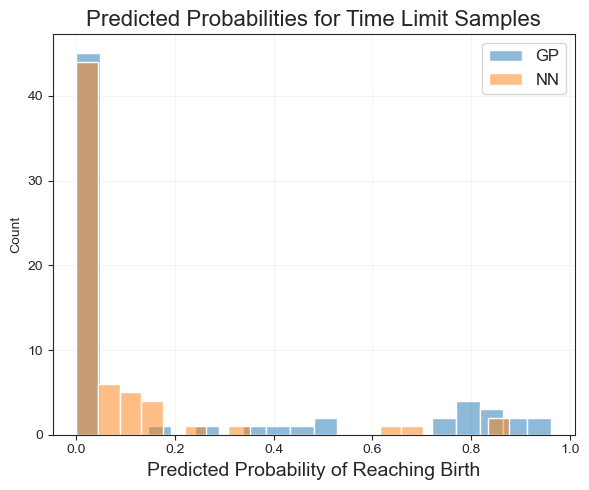

In [60]:
gp_time_limit_probs = gp_test_set_probs[time_limit_indices]
nn_time_limit_probs = nn_test_set_probs[time_limit_indices]

# PLot histogram of probabilities for time limit samples
fig, ax = plt.subplots(figsize=(6, 5))
# ax.hist(gp_time_limit_probs[:, 1], bins=20, alpha=0.5, label='GP', color='tab:blue')
if isinstance(nn_time_limit_probs, torch.Tensor):
    nn_time_limit_probs = nn_time_limit_probs.cpu().detach().numpy()
# ax.hist(nn_time_limit_probs.squeeze(), bins=20, alpha=0.5, label='NN', color='tab:orange')
sns.histplot(gp_time_limit_probs[:, 1], bins=20, alpha=0.5, label='GP')
sns.histplot(nn_time_limit_probs.squeeze(), bins=20, alpha=0.5, label='NN')
ax.set_xlabel("Predicted Probability of Reaching Birth", fontsize=14)
# ax.set_ylabel("Count", fontsize=14)
ax.set_title("Predicted Probabilities for Time Limit Samples", fontsize=16)
ax.legend(loc="best", fontsize=12)
ax.grid(alpha=0.2)
fig.tight_layout()

In [70]:
61/65

0.9384615384615385